In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Membaca dataset asli yang Anda unggah
# Sesuaikan jalur ('/content/HR-Employee-Attrition.csv') jika Anda menyimpannya di folder lain
df_ibm = pd.read_csv('HR-Employee-Attrition.csv')

print(f"Dataset berhasil dimuat! Total baris: {df_ibm.shape[0]}, Total kolom: {df_ibm.shape[1]}")

Dataset berhasil dimuat! Total baris: 1470, Total kolom: 35


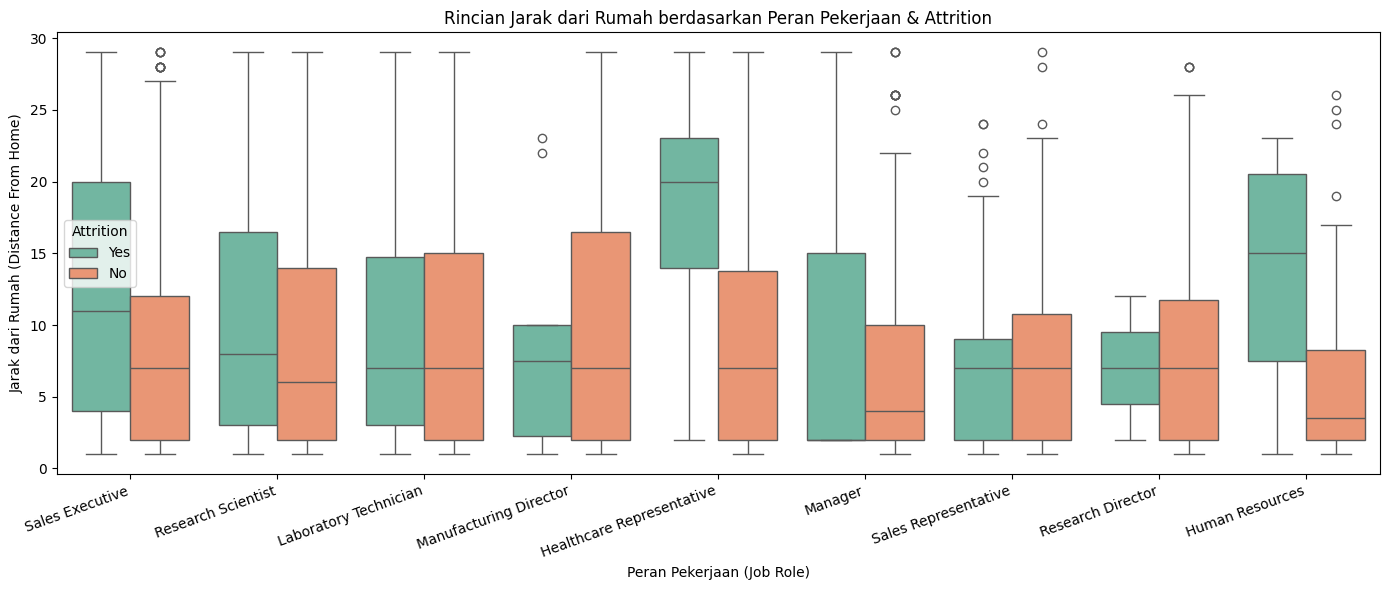

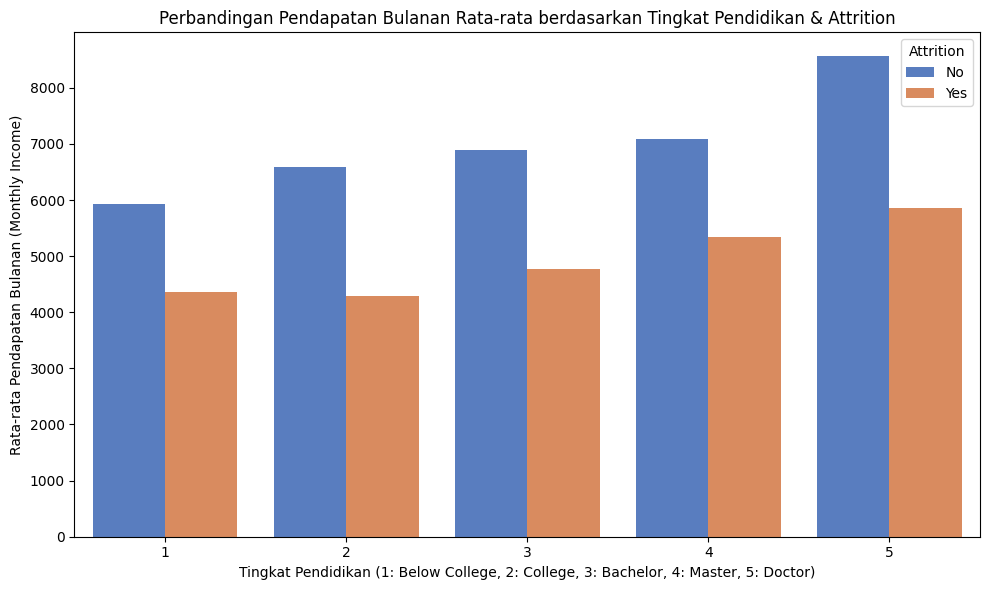

In [13]:
# 1. Rincian jarak dari rumah berdasarkan peran pekerjaan dan pengunduran diri (Attrition)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_ibm, x='JobRole', y='DistanceFromHome', hue='Attrition', palette='Set2')
plt.title('Rincian Jarak dari Rumah berdasarkan Peran Pekerjaan & Attrition')
plt.xlabel('Peran Pekerjaan (Job Role)')
plt.ylabel('Jarak dari Rumah (Distance From Home)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# 2. Bandingkan pendapatan bulanan rata-rata berdasarkan pendidikan dan pengunduran diri
# Catatan: Di dataset IBM, kolom Pendidikan bertipe angka (1-5). Kita bisa memplotnya langsung.
plt.figure(figsize=(10, 6))
sns.barplot(data=df_ibm, x='Education', y='MonthlyIncome', hue='Attrition', errorbar=None, palette='muted')
plt.title('Perbandingan Pendapatan Bulanan Rata-rata berdasarkan Tingkat Pendidikan & Attrition')
plt.xlabel('Tingkat Pendidikan (1: Below College, 2: College, 3: Bachelor, 4: Master, 5: Doctor)')
plt.ylabel('Rata-rata Pendapatan Bulanan (Monthly Income)')
plt.tight_layout()
plt.show()

In [14]:
# Membuat salinan dataframe untuk rekayasa fitur
df_encoded = df_ibm.copy()

# 1. Mengubah target 'Attrition' menjadi biner (Yes -> 1, No -> 0)
le_target = LabelEncoder()
df_encoded['Attrition'] = le_target.fit_transform(df_encoded['Attrition'])

# 2. Otomatisasi Label Encoding untuk semua kolom bertipe objek/teks lainnya
kategori_cols = df_encoded.select_dtypes(include=['object']).columns

label_encoders = {}
for col in kategori_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print("Proses encoding selesai. Beberapa kolom bertekstur teks kini telah dikodekan menjadi numerik:")
display(df_encoded[['Attrition', 'JobRole', 'BusinessTravel', 'OverTime', 'MonthlyIncome']].head())

Proses encoding selesai. Beberapa kolom bertekstur teks kini telah dikodekan menjadi numerik:


,Attrition,JobRole,BusinessTravel,OverTime,MonthlyIncome
0,1,7,2,1,5993
1,0,6,1,0,5130
2,1,2,2,1,2090
3,0,6,1,1,2909
4,0,2,2,0,3468


--- Laporan Evaluasi Model ---
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.43      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.64      0.52      0.51       294
weighted avg       0.78      0.84      0.78       294



/tmp/ipykernel_13490/3177403968.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Tingkat Pengaruh', y='Faktor/Fitur', palette='viridis')


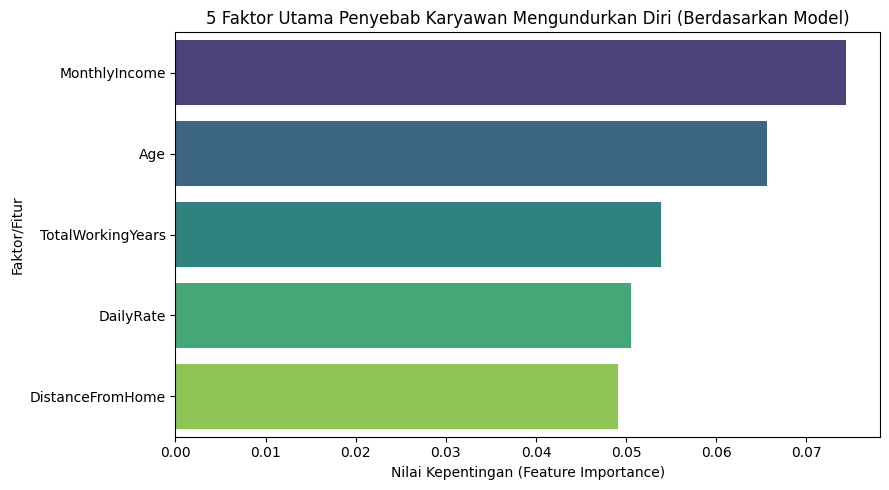

In [15]:
# 1. Memisahkan Fitur (X) dan Target (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Menghapus kolom yang tidak memiliki variansi (jika ada kolom konstan seperti EmployeeCount, Over18, StandardHours)
kolom_konstan = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=kolom_konstan)

# 2. Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Implementasi Model Random Forest Classifier
model_hr = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_hr.fit(X_train, y_train)

# 4. Evaluasi Performa Model
y_pred = model_hr.predict(X_test)
print("--- Laporan Evaluasi Model ---")
print(classification_report(y_test, y_pred))

# 5. Mengambil Faktor Utama Penyebab Resign (Feature Importance)
importances = model_hr.feature_importances_
df_importance = pd.DataFrame({'Faktor/Fitur': X.columns, 'Tingkat Pengaruh': importances})
df_importance = df_importance.sort_values(by='Tingkat Pengaruh', ascending=False).head(5)

# Plot Faktor Utama
plt.figure(figsize=(9, 5))
sns.barplot(data=df_importance, x='Tingkat Pengaruh', y='Faktor/Fitur', palette='viridis')
plt.title('5 Faktor Utama Penyebab Karyawan Mengundurkan Diri (Berdasarkan Model)')
plt.xlabel('Nilai Kepentingan (Feature Importance)')
plt.tight_layout()
plt.show()